In [6]:
#DATA PROCESSING

import pandas as pd
import numpy as np

# Reload raw data file
raw_loaded = pd.read_csv(
    "raw_yfinance_daily_data.csv",
    header=[0, 1],   # MultiIndex columns from yfinance
    index_col=0,
    parse_dates=True
)

print("Reloaded raw data preview:")
print(raw_loaded.head())
print("\nReloaded raw columns:")
print(raw_loaded.columns)

# Extract Close prices only
if isinstance(raw_loaded.columns, pd.MultiIndex):
    if "Close" in raw_loaded.columns.get_level_values(0):
        prices = raw_loaded["Close"].copy()
    else:
        prices = raw_loaded.xs("Close", axis=1, level=0).copy()
else:
    prices = raw_loaded.copy()

prices.columns = [str(c) for c in prices.columns]
prices = prices.dropna().copy()

print("\nExtracted close price data preview:")
print(prices.head())
print("\nPrice columns:")
print(prices.columns.tolist())

# Save daily close-price data
prices.to_csv("close_prices_daily.csv")

# Convert to month-end prices
monthly_prices = prices.resample("M").last().copy()

print("\nMonthly prices preview:")
print(monthly_prices.head())

monthly_prices.to_csv("monthly_prices.csv")

# Compute monthly returns

monthly_returns = monthly_prices.pct_change().dropna().copy()

print("\nMonthly returns preview:")
print(monthly_returns.head())

print("\nMonthly return summary:")
print(monthly_returns.describe())

monthly_returns.to_csv("monthly_returns.csv")

# Create modeling dataframe
# Forecast next-month JETS using lagged info only
df = monthly_returns.copy()

# Lagged oil returns
for lag in [1, 2, 3, 6]:
    df[f"oil_lag_{lag}"] = df["CL=F"].shift(lag)

# Lagged SPY returns
for lag in [1, 2, 3]:
    df[f"spy_lag_{lag}"] = df["SPY"].shift(lag)

# Lagged JETS returns
for lag in [1, 2, 3, 6]:
    df[f"jets_lag_{lag}"] = df["JETS"].shift(lag)

# Optional rolling vol features
df["oil_vol_3"] = df["CL=F"].rolling(3).std().shift(1)
df["spy_vol_3"] = df["SPY"].rolling(3).std().shift(1)
df["jets_vol_3"] = df["JETS"].rolling(3).std().shift(1)

# Target = next month's JETS return
df["target_next_jets"] = df["JETS"].shift(-1)

df = df.dropna().copy()

print("\nModeling dataframe preview:")
print(df.head())
print("\nModeling dataframe columns:")
print(df.columns.tolist())
print("\nShape:", df.shape)

df.to_csv("modeling_dataframe.csv")

print("\nSaved processed files:")
print("- close_prices_daily.csv")
print("- monthly_prices.csv")
print("- monthly_returns.csv")
print("- modeling_dataframe.csv")

Reloaded raw data preview:
Price           Close                       High                        Low  \
Ticker           CL=F JETS        SPY       CL=F JETS        SPY       CL=F   
Date                                                                          
2010-01-04  81.510002  NaN  85.027954  81.680000  NaN  85.072968  79.629997   
2010-01-05  81.769997  NaN  85.253029  82.000000  NaN  85.290545  80.949997   
2010-01-06  83.180000  NaN  85.313042  83.519997  NaN  85.523116  80.849998   
2010-01-07  82.660004  NaN  85.673210  83.360001  NaN  85.778247  82.260002   
2010-01-08  82.750000  NaN  85.958313  83.470001  NaN  85.995829  81.800003   

Price                            Open                    Volume       \
Ticker     JETS        SPY       CL=F JETS        SPY      CL=F JETS   
Date                                                                   
2010-01-04  NaN  83.662465  79.629997  NaN  84.307697  263542.0  NaN   
2010-01-05  NaN  84.667820  81.629997  NaN  84.97543

Loaded files successfully.

Daily prices preview:
                 CL=F       JETS         SPY
Date                                        
2015-04-30  59.630001  22.858271  173.878448
2015-05-01  59.150002  23.502777  175.763535
2015-05-04  58.930000  23.304323  176.264008
2015-05-05  60.400002  22.680607  174.245438
2015-05-06  60.930000  22.661707  173.528137

Monthly returns preview:
                CL=F      JETS       SPY
Date                                    
2015-05-31  0.011236 -0.044981  0.012856
2015-06-30 -0.013764 -0.030736 -0.020312
2015-07-31 -0.207668  0.052255  0.022590
2015-08-31  0.044143 -0.032258 -0.060950
2015-09-30 -0.083537  0.017982 -0.025516

Modeling dataframe preview:
                CL=F      JETS       SPY  oil_lag_1  oil_lag_2  oil_lag_3  \
Date                                                                        
2015-11-30 -0.106031 -0.038971  0.003655   0.033267  -0.083537   0.044143   
2015-12-31 -0.110684  0.012253 -0.017283  -0.106031   0.033267

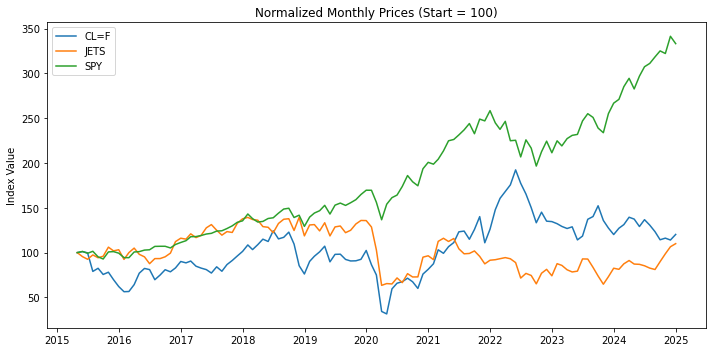

Saved figure: figures/02_monthly_returns.png


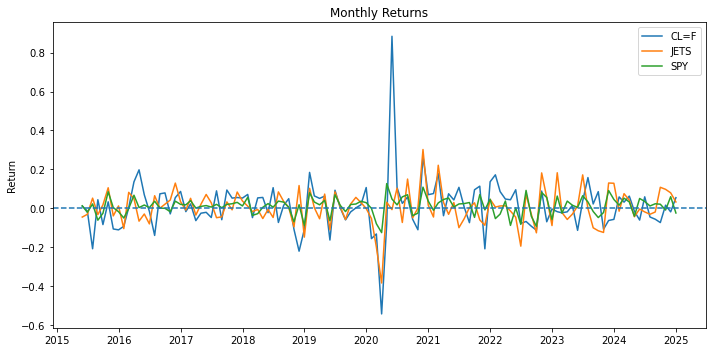


Correlation matrix:
          CL=F      JETS       SPY
CL=F  1.000000  0.333670  0.351519
JETS  0.333670  1.000000  0.682777
SPY   0.351519  0.682777  1.000000
Saved figure: figures/03_correlation_matrix.png


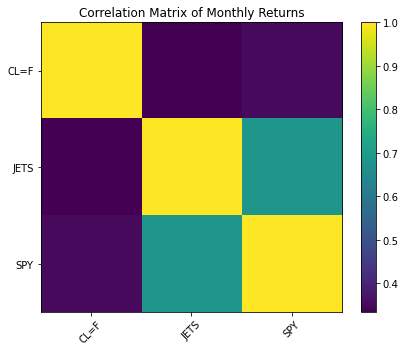


Monthly return summary statistics:
             CL=F        JETS         SPY
count  116.000000  116.000000  116.000000
mean     0.009800    0.004819    0.011417
std      0.131411    0.088039    0.044586
min     -0.542449   -0.383682   -0.124871
25%     -0.059628   -0.044757   -0.016375
50%      0.014897    0.003593    0.017373
75%      0.069472    0.050431    0.037047
max      0.883758    0.302010    0.126984
Saved: monthly_return_summary_statistics.csv
Saved figure: figures/04_rolling_correlation_oil_jets.png


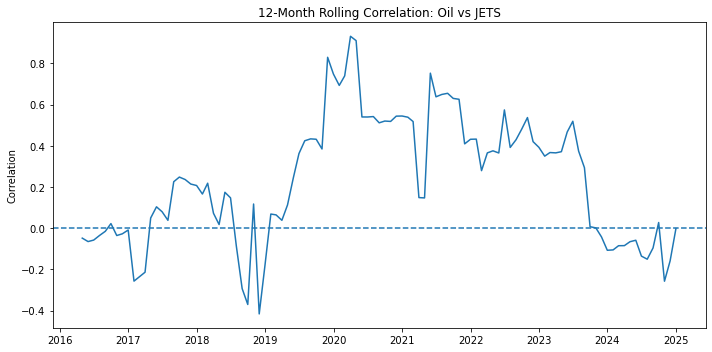


Train size: (87, 18)
Test size: (22, 18)

Full model comparison results:
                               model       mse      rmse       mae  \
0               OLS: Lagged Oil only  0.006534  0.080833  0.064821   
1                    Historical Mean  0.006558  0.080979  0.065424   
2             LassoCV: Full features  0.006558  0.080979  0.065424   
3        ElasticNetCV: Full features  0.006558  0.080979  0.065424   
4             RidgeCV: Full features  0.006572  0.081067  0.065479   
5                      Zero Baseline  0.006622  0.081376  0.065204   
6               OLS: Lagged SPY only  0.006707  0.081898  0.065604   
7                 AR: JETS lags only  0.006981  0.083555  0.065774   
8       OLS: Lagged Oil + Lagged SPY  0.007188  0.084782  0.066322   
9               Huber: Full features  0.007608  0.087226  0.073216   
10      Random Forest: Full features  0.008376  0.091518  0.070239   
11                    Naive Momentum  0.008717  0.093364  0.065817   
12  Gradient Boo

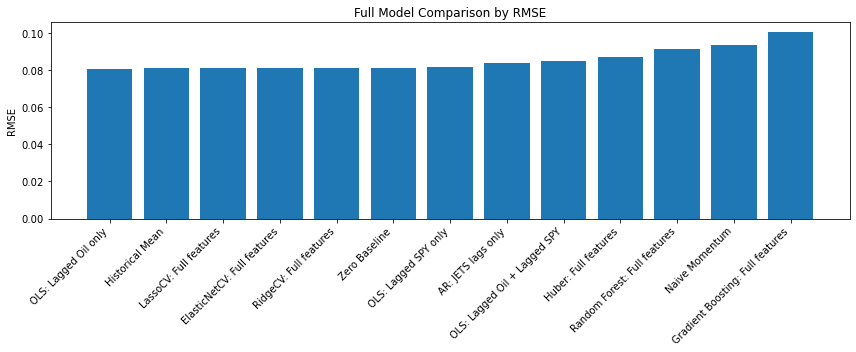

Saved figure: figures/06_full_model_comparison_directional_accuracy.png


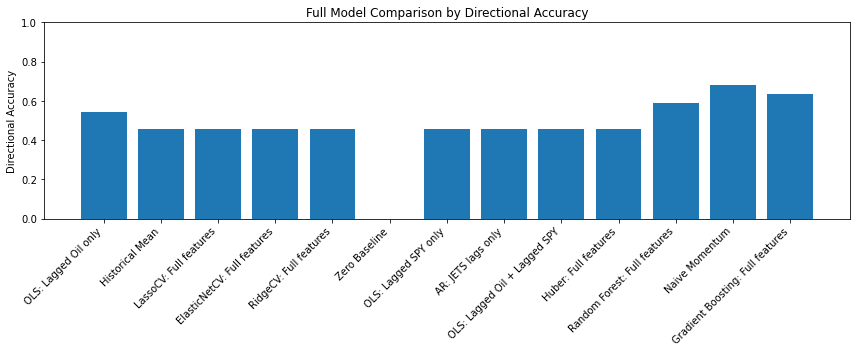


Presentation-focused model comparison:
                          model       mse      rmse       mae  \
0          OLS: Lagged Oil only  0.006534  0.080833  0.064821   
1               Historical Mean  0.006558  0.080979  0.065424   
2          OLS: Lagged SPY only  0.006707  0.081898  0.065604   
3  OLS: Lagged Oil + Lagged SPY  0.007188  0.084782  0.066322   
4                Naive Momentum  0.008717  0.093364  0.065817   

   corr_actual_pred  directional_accuracy          family    color  
0      4.705640e-02              0.545455       Oil model  #E45756  
1      4.333193e-17              0.454545       Benchmark  #7A7A7A  
2     -1.225700e-01              0.454545    Market model  #F2B134  
3     -1.406549e-01              0.454545  Combined model  #7B4EA3  
4      3.226691e-01              0.681818     Persistence  #4C78A8  

Presentation family summary:
                          model          family      rmse  \
0          OLS: Lagged Oil only       Oil model  0.080833   
1  

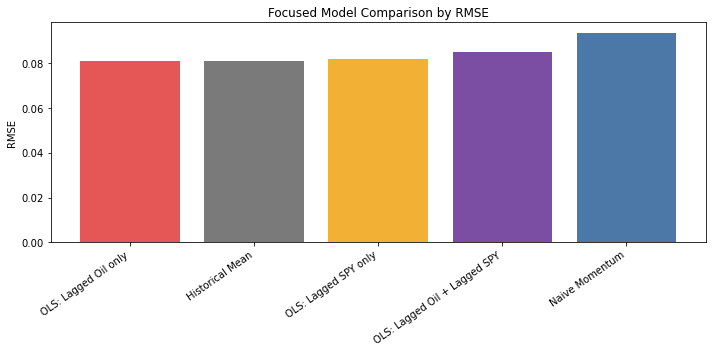

Saved figure: figures/08_focused_model_comparison_directional_accuracy.png


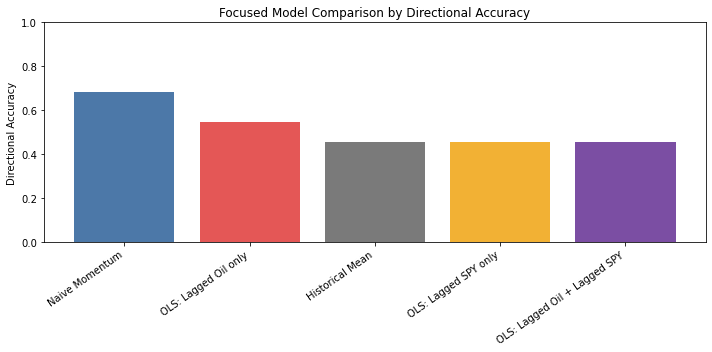


Best presentation model by RMSE: OLS: Lagged Oil only

Actual vs Predicted preview (presentation model):
              Actual  Predicted
Date                           
2023-02-28 -0.057186   0.012664
2023-03-31 -0.030059   0.004807
2023-04-30  0.011622   0.005620
2023-05-31  0.171772   0.003566
2023-06-30 -0.001401   0.017558
Saved figure: figures/09_actual_vs_predicted_best_presentation_model.png


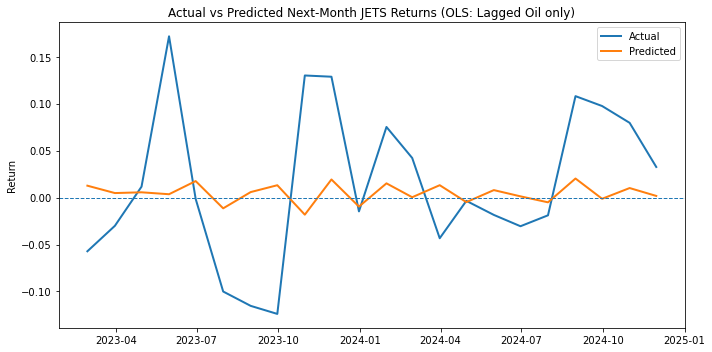

Saved figure: figures/10_best_rmse_by_model_family.png


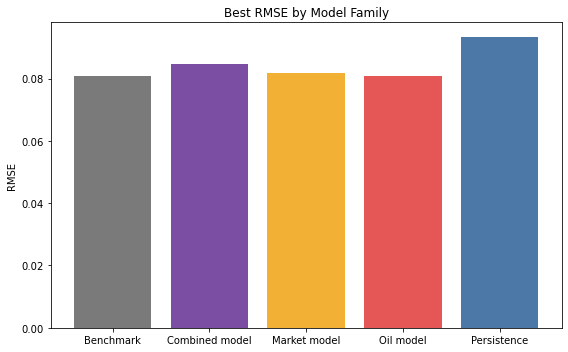


Saved outputs:
- jets_expanded_model_comparison_results.csv
- presentation_model_comparison.csv
- presentation_family_summary.csv
- presentation_actual_vs_predicted.csv
- best_rmse_by_family.csv
- monthly_return_summary_statistics.csv
- coefficient tables for linear / regularized models
- all figures saved in folder: figures


In [5]:
#STATISTICAL ANALYSIS & VISUALIZATION

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV,
    ElasticNetCV,
    HuberRegressor
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Figure output folder
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_current_figure(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {path}")

# Load processed data
prices = pd.read_csv("close_prices_daily.csv", index_col=0, parse_dates=True)
monthly_prices = pd.read_csv("monthly_prices.csv", index_col=0, parse_dates=True)
monthly_returns = pd.read_csv("monthly_returns.csv", index_col=0, parse_dates=True)
df = pd.read_csv("modeling_dataframe.csv", index_col=0, parse_dates=True)

print("Loaded files successfully.")
print("\nDaily prices preview:")
print(prices.head())
print("\nMonthly returns preview:")
print(monthly_returns.head())
print("\nModeling dataframe preview:")
print(df.head())

# Exploratory plots:

# EDA: Normalized monthly prices
normalized_prices = monthly_prices / monthly_prices.iloc[0] * 100

plt.figure(figsize=(10, 5))
x_norm = normalized_prices.index.to_numpy()

for col in normalized_prices.columns:
    y = normalized_prices[col]
    if isinstance(y, pd.DataFrame):
        y = y.squeeze()
    plt.plot(x_norm, y.to_numpy(), label=str(col))

plt.title("Normalized Monthly Prices (Start = 100)")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
save_current_figure("01_normalized_monthly_prices.png")
plt.show()

# EDA: Monthly returns
plt.figure(figsize=(10, 5))
x_ret = monthly_returns.index.to_numpy()

for col in monthly_returns.columns:
    y = monthly_returns[col]
    if isinstance(y, pd.DataFrame):
        y = y.squeeze()
    plt.plot(x_ret, y.to_numpy(), label=str(col))

plt.axhline(0, linestyle="--")
plt.title("Monthly Returns")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
save_current_figure("02_monthly_returns.png")
plt.show()

# EDA: Correlation matrix
corr = monthly_returns.corr()
print("\nCorrelation matrix:")
print(corr)

plt.figure(figsize=(6, 5))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix of Monthly Returns")
plt.tight_layout()
save_current_figure("03_correlation_matrix.png")
plt.show()

# EDA: Summary statistics table
print("\nMonthly return summary statistics:")
print(monthly_returns.describe())

# Save summary stats table as CSV
monthly_returns.describe().to_csv("monthly_return_summary_statistics.csv")
print("Saved: monthly_return_summary_statistics.csv")

# EDA: rolling 12-month correlation between oil and JETS
rolling_corr = monthly_returns["CL=F"].rolling(12).corr(monthly_returns["JETS"])

plt.figure(figsize=(10, 5))
plt.plot(rolling_corr.index.to_numpy(), rolling_corr.to_numpy())
plt.axhline(0, linestyle="--")
plt.title("12-Month Rolling Correlation: Oil vs JETS")
plt.ylabel("Correlation")
plt.tight_layout()
save_current_figure("04_rolling_correlation_oil_jets.png")
plt.show()

# Train/test split
target = "target_next_jets"
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

y_train = train[target].to_numpy()
y_test = test[target].to_numpy()

print("\nTrain size:", train.shape)
print("Test size:", test.shape)


# Evaluation helper(predictions)
def evaluate_predictions(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)

    if len(y_true) > 1 and np.std(y_pred) > 0:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        corr = np.nan

    directional_accuracy = (np.sign(y_true) == np.sign(y_pred)).mean()

    return {
        "model": model_name,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "corr_actual_pred": corr,
        "directional_accuracy": directional_accuracy
    }

# Featured sets for models
feature_sets = {
    "AR: JETS lags only": [
        "jets_lag_1", "jets_lag_2", "jets_lag_3", "jets_lag_6"
    ],
    "OLS: Lagged SPY only": [
        "spy_lag_1", "spy_lag_2", "spy_lag_3"
    ],
    "OLS: Lagged Oil only": [
        "oil_lag_1", "oil_lag_2", "oil_lag_3", "oil_lag_6"
    ],
    "OLS: Lagged Oil + Lagged SPY": [
        "oil_lag_1", "oil_lag_2", "oil_lag_3", "oil_lag_6",
        "spy_lag_1", "spy_lag_2", "spy_lag_3"
    ],
    "Full features": [
        "oil_lag_1", "oil_lag_2", "oil_lag_3", "oil_lag_6",
        "spy_lag_1", "spy_lag_2", "spy_lag_3",
        "jets_lag_1", "jets_lag_2", "jets_lag_3", "jets_lag_6",
        "oil_vol_3", "spy_vol_3", "jets_vol_3"
    ]
}

## Baseline model definitions

results = []
predictions = {}

# Zero baseline
pred_zero = np.zeros(len(test))
results.append(evaluate_predictions(y_test, pred_zero, "Zero Baseline"))
predictions["Zero Baseline"] = pred_zero

# Historical mean
train_mean = y_train.mean()
pred_mean = np.full(len(test), train_mean)
results.append(evaluate_predictions(y_test, pred_mean, "Historical Mean"))
predictions["Historical Mean"] = pred_mean

# Naive momentum
pred_naive = test["JETS"].to_numpy()
results.append(evaluate_predictions(y_test, pred_naive, "Naive Momentum"))
predictions["Naive Momentum"] = pred_naive

## More Complex model definitions
tscv = TimeSeriesSplit(n_splits=5)

models_to_run = [
    {
        "name": "AR: JETS lags only",
        "features": feature_sets["AR: JETS lags only"],
        "estimator": LinearRegression()
    },
    {
        "name": "OLS: Lagged SPY only",
        "features": feature_sets["OLS: Lagged SPY only"],
        "estimator": LinearRegression()
    },
    {
        "name": "OLS: Lagged Oil only",
        "features": feature_sets["OLS: Lagged Oil only"],
        "estimator": LinearRegression()
    },
    {
        "name": "OLS: Lagged Oil + Lagged SPY",
        "features": feature_sets["OLS: Lagged Oil + Lagged SPY"],
        "estimator": LinearRegression()
    },
    {
        "name": "RidgeCV: Full features",
        "features": feature_sets["Full features"],
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(
                alphas=np.logspace(-4, 4, 50),
                cv=tscv
            ))
        ])
    },
    {
        "name": "LassoCV: Full features",
        "features": feature_sets["Full features"],
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(
                alphas=np.logspace(-4, 1, 50),
                cv=tscv,
                max_iter=20000
            ))
        ])
    },
    {
        "name": "ElasticNetCV: Full features",
        "features": feature_sets["Full features"],
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                alphas=np.logspace(-4, 1, 40),
                cv=tscv,
                max_iter=20000
            ))
        ])
    },
    {
        "name": "Huber: Full features",
        "features": feature_sets["Full features"],
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", HuberRegressor())
        ])
    },
    {
        "name": "Random Forest: Full features",
        "features": feature_sets["Full features"],
        "estimator": RandomForestRegressor(
            n_estimators=300,
            max_depth=4,
            min_samples_leaf=3,
            random_state=42
        )
    },
    {
        "name": "Gradient Boosting: Full features",
        "features": feature_sets["Full features"],
        "estimator": GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            random_state=42
        )
    }
]

# Fitting all models

coef_tables = {}

for spec in models_to_run:
    model_name = spec["name"]
    feature_cols = spec["features"]
    estimator = clone(spec["estimator"])

    X_train = train[feature_cols]
    X_test = test[feature_cols]

    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)

    results.append(evaluate_predictions(y_test, y_pred, model_name))
    predictions[model_name] = y_pred

    if hasattr(estimator, "coef_"):
        coef_tables[model_name] = pd.DataFrame({
            "feature": feature_cols,
            "coefficient": estimator.coef_
        })
    elif isinstance(estimator, Pipeline):
        final_model = estimator.named_steps.get("model", None)
        if final_model is not None and hasattr(final_model, "coef_"):
            coef_tables[model_name] = pd.DataFrame({
                "feature": feature_cols,
                "coefficient": final_model.coef_
            })

# Full results table
results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

print("\nFull model comparison results:")
print(results_df)

results_df.to_csv("jets_expanded_model_comparison_results.csv", index=False)

# Full charts to compare
plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["rmse"])
plt.title("Full Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_current_figure("05_full_model_comparison_rmse.png")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["directional_accuracy"])
plt.title("Full Model Comparison by Directional Accuracy")
plt.ylabel("Directional Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_current_figure("06_full_model_comparison_directional_accuracy.png")
plt.show()


# For Presentation- model-focused sets
# =========================================================
presentation_models = [
    "Historical Mean",
    "Naive Momentum",
    "OLS: Lagged SPY only",
    "OLS: Lagged Oil only",
    "OLS: Lagged Oil + Lagged SPY"
]

results_present = (
    results_df[results_df["model"].isin(presentation_models)]
    .copy()
    .reset_index(drop=True)
)

# Grouping models into families
family_map = {
    "Historical Mean": "Benchmark",
    "Naive Momentum": "Persistence",
    "OLS: Lagged SPY only": "Market model",
    "OLS: Lagged Oil only": "Oil model",
    "OLS: Lagged Oil + Lagged SPY": "Combined model"
}

color_map = {
    "Benchmark": "#7A7A7A",       # gray
    "Persistence": "#4C78A8",     # blue
    "Market model": "#F2B134",    # gold
    "Oil model": "#E45756",       # red
    "Combined model": "#7B4EA3"   # purple
}

results_present["family"] = results_present["model"].map(family_map)
results_present["color"] = results_present["family"].map(color_map)

print("\nPresentation-focused model comparison:")
print(results_present)

results_present.to_csv("presentation_model_comparison.csv", index=False)

# Family summary table
family_summary = results_present[["model", "family", "rmse", "directional_accuracy"]].copy()
print("\nPresentation family summary:")
print(family_summary)
family_summary.to_csv("presentation_family_summary.csv", index=False)


# RMSE plots
rmse_order = results_present.sort_values("rmse").copy()

plt.figure(figsize=(10, 5))
plt.bar(
    rmse_order["model"],
    rmse_order["rmse"],
    color=rmse_order["color"]
)
plt.title("Focused Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
save_current_figure("07_focused_model_comparison_rmse.png")
plt.show()

# Directional accuracy plot
dir_order = results_present.sort_values("directional_accuracy", ascending=False).copy()

plt.figure(figsize=(10, 5))
plt.bar(
    dir_order["model"],
    dir_order["directional_accuracy"],
    color=dir_order["color"]
)
plt.title("Focused Model Comparison by Directional Accuracy")
plt.ylabel("Directional Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
save_current_figure("08_focused_model_comparison_directional_accuracy.png")
plt.show()


# Actual vs predicted for best presentation model
best_present_model = rmse_order.iloc[0]["model"]
best_present_pred = predictions[best_present_model]

print("\nBest presentation model by RMSE:", best_present_model)

pred_df_present = pd.DataFrame({
    "Actual": y_test,
    "Predicted": best_present_pred
}, index=test.index)

print("\nActual vs Predicted preview (presentation model):")
print(pred_df_present.head())

pred_df_present.to_csv("presentation_actual_vs_predicted.csv")

plt.figure(figsize=(10, 5))
plt.plot(
    pred_df_present.index.to_numpy(),
    pred_df_present["Actual"].to_numpy(),
    label="Actual",
    linewidth=2
)
plt.plot(
    pred_df_present.index.to_numpy(),
    pred_df_present["Predicted"].to_numpy(),
    label="Predicted",
    linewidth=2
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Actual vs Predicted Next-Month JETS Returns ({best_present_model})")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
save_current_figure("09_actual_vs_predicted_best_presentation_model.png")
plt.show()


# family-best RMSE plot
family_best = (
    results_present.sort_values("rmse")
    .groupby("family", as_index=False)
    .first()
)

family_best.to_csv("best_rmse_by_family.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(
    family_best["family"],
    family_best["rmse"],
    color=family_best["family"].map(color_map)
)
plt.title("Best RMSE by Model Family")
plt.ylabel("RMSE")
plt.tight_layout()
save_current_figure("10_best_rmse_by_model_family.png")
plt.show()

# Saving coefficient tables
for model_name, table in coef_tables.items():
    safe_name = (
        model_name.lower()
        .replace(":", "")
        .replace(" ", "_")
        .replace("+", "plus")
    )
    table.to_csv(f"{safe_name}_coefficients.csv", index=False)

print("\nSaved outputs:")
print("- jets_expanded_model_comparison_results.csv")
print("- presentation_model_comparison.csv")
print("- presentation_family_summary.csv")
print("- presentation_actual_vs_predicted.csv")
print("- best_rmse_by_family.csv")
print("- monthly_return_summary_statistics.csv")
print("- coefficient tables for linear / regularized models")
print(f"- all figures saved in folder: {FIG_DIR}")